# Logistic Regression Project (Predict Ad click)

In this notebook we will use `Logistic Regression` to indicating whether or not a particular internet user clicked on an Advertisement. We will try to create a model that will predict whether or not they will click on an ad based off the features of that user.  
En este cuaderno, utilizaremos la regresión logística para indicar si un usuario de internet hizo clic en un anuncio. Intentaremos crear un modelo que prediga si hará clic en un anuncio según las características de ese usuario.

This data set contains the following features:  
Este conjunto de datos contiene las siguientes características:

* '`Daily Time Spent on Site`': consumer time on site in minutes  
«Tiempo diario en el sitio»: tiempo del consumidor en el sitio en minutos  
* '`Age`': customer age in years  
«Edad»: edad del cliente en años  
* '`Area Income`': Avg. Income of geographical area of consumer  
«Ingresos por zona»: ingreso promedio del área geográfica del consumidor  
* '`Daily Internet Usage`': Avg. minutes a day consumer is on the internet  
«Uso diario de internet»: promedio de minutos diarios que el consumidor pasa en internet  
* '`Ad Topic Line`': Headline of the advertisement  
«Tema del anuncio»: título del anuncio  
* '`City`': City of consumer  
«Ciudad»: ciudad del consumidor  
* '`Male`': Whether or not consumer was male  
«Hombre»: si el consumidor era hombre o no  
* '`Country`': Country of consumer  
«País»: país del consumidor  
* '`Timestamp`': Time at which consumer clicked on Ad or closed window  
«Marca de tiempo»: hora en que el consumidor hizo clic en el anuncio o cerró la ventana  
* '`Clicked on Ad`': 0 or 1 indicated clicking on Ad  
«Clic en el anuncio»: 0 o 1 indica que hizo clic en el anuncio

## Get the Data

In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix


In [4]:
df = pd.read_csv('data/advertising.csv')
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


# 1. Exploratory Data Analysis

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 78.3+ KB


In [6]:
df.describe()


,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,65.000200,36.009000,55000.000080,180.000100,0.481000,0.50000
std,15.853615,8.785562,13414.634022,43.902339,0.499889,0.50025
min,32.600000,19.000000,13996.500000,104.780000,0.000000,0.00000
25%,51.360000,29.000000,47031.802500,138.830000,0.000000,0.00000
50%,68.215000,35.000000,57012.300000,183.130000,0.000000,0.50000
75%,78.547500,42.000000,65470.635000,218.792500,1.000000,1.00000
max,91.430000,61.000000,79484.800000,269.960000,1.000000,1.00000


In [7]:
df['Clicked on Ad'].value_counts(normalize=True)

Clicked on Ad
0    0.5
1    0.5
Name: proportion, dtype: float64

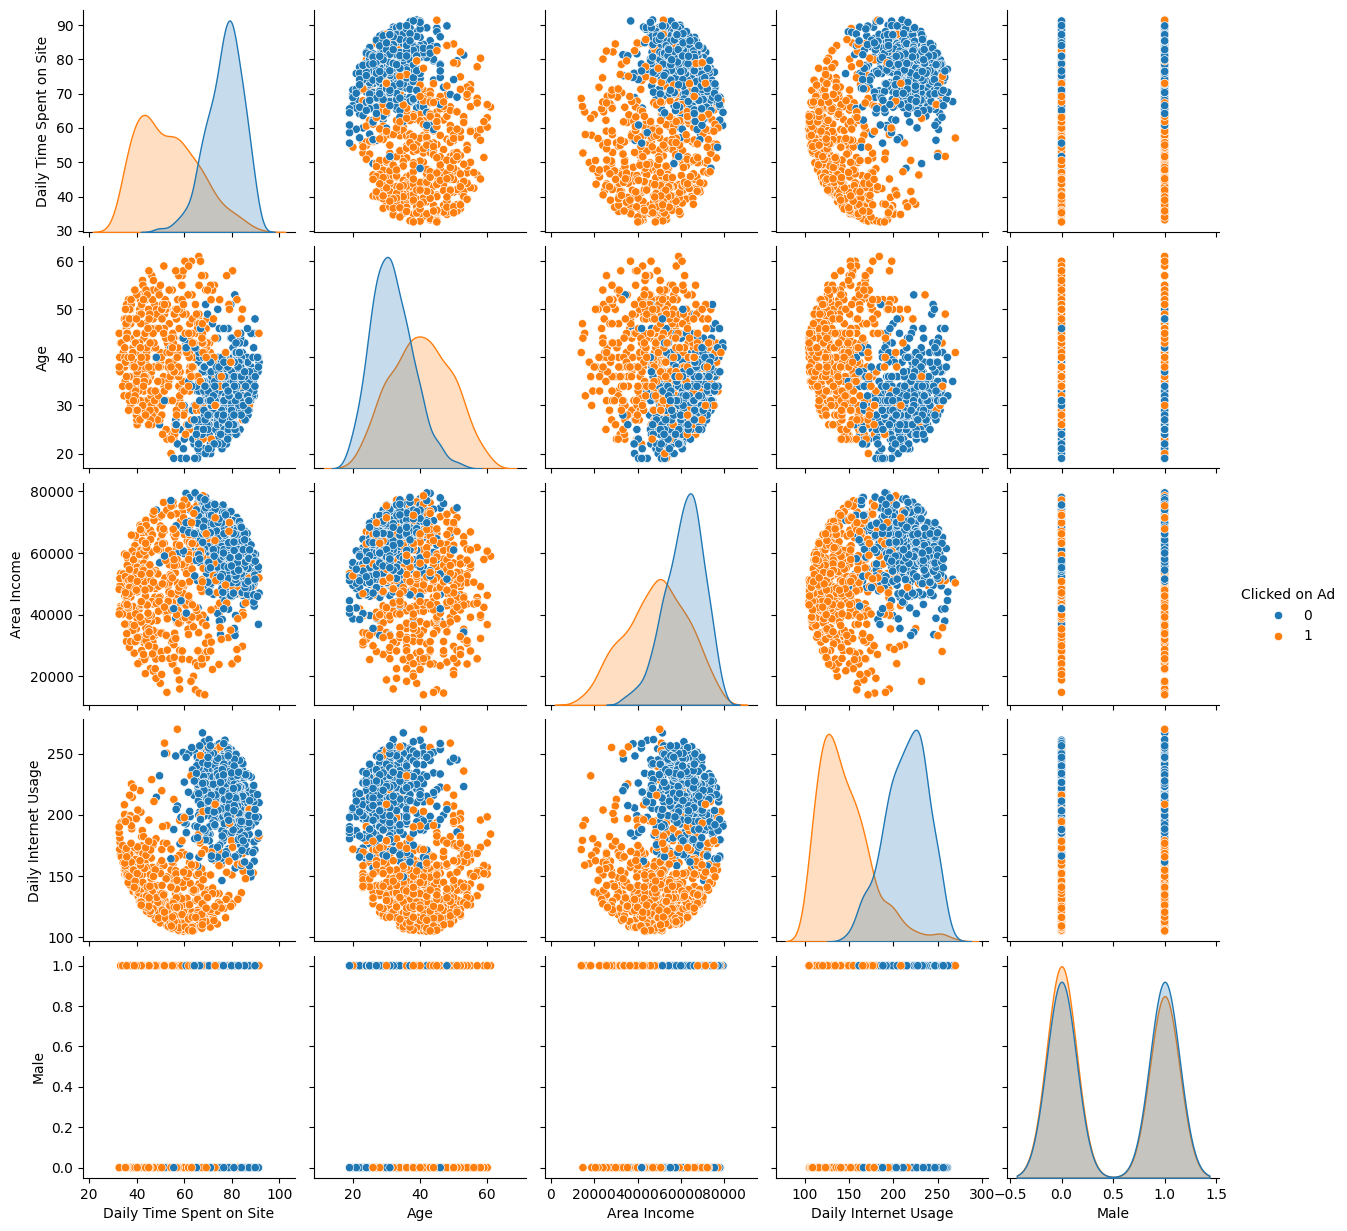

In [8]:
sns.pairplot(df, hue='Clicked on Ad')

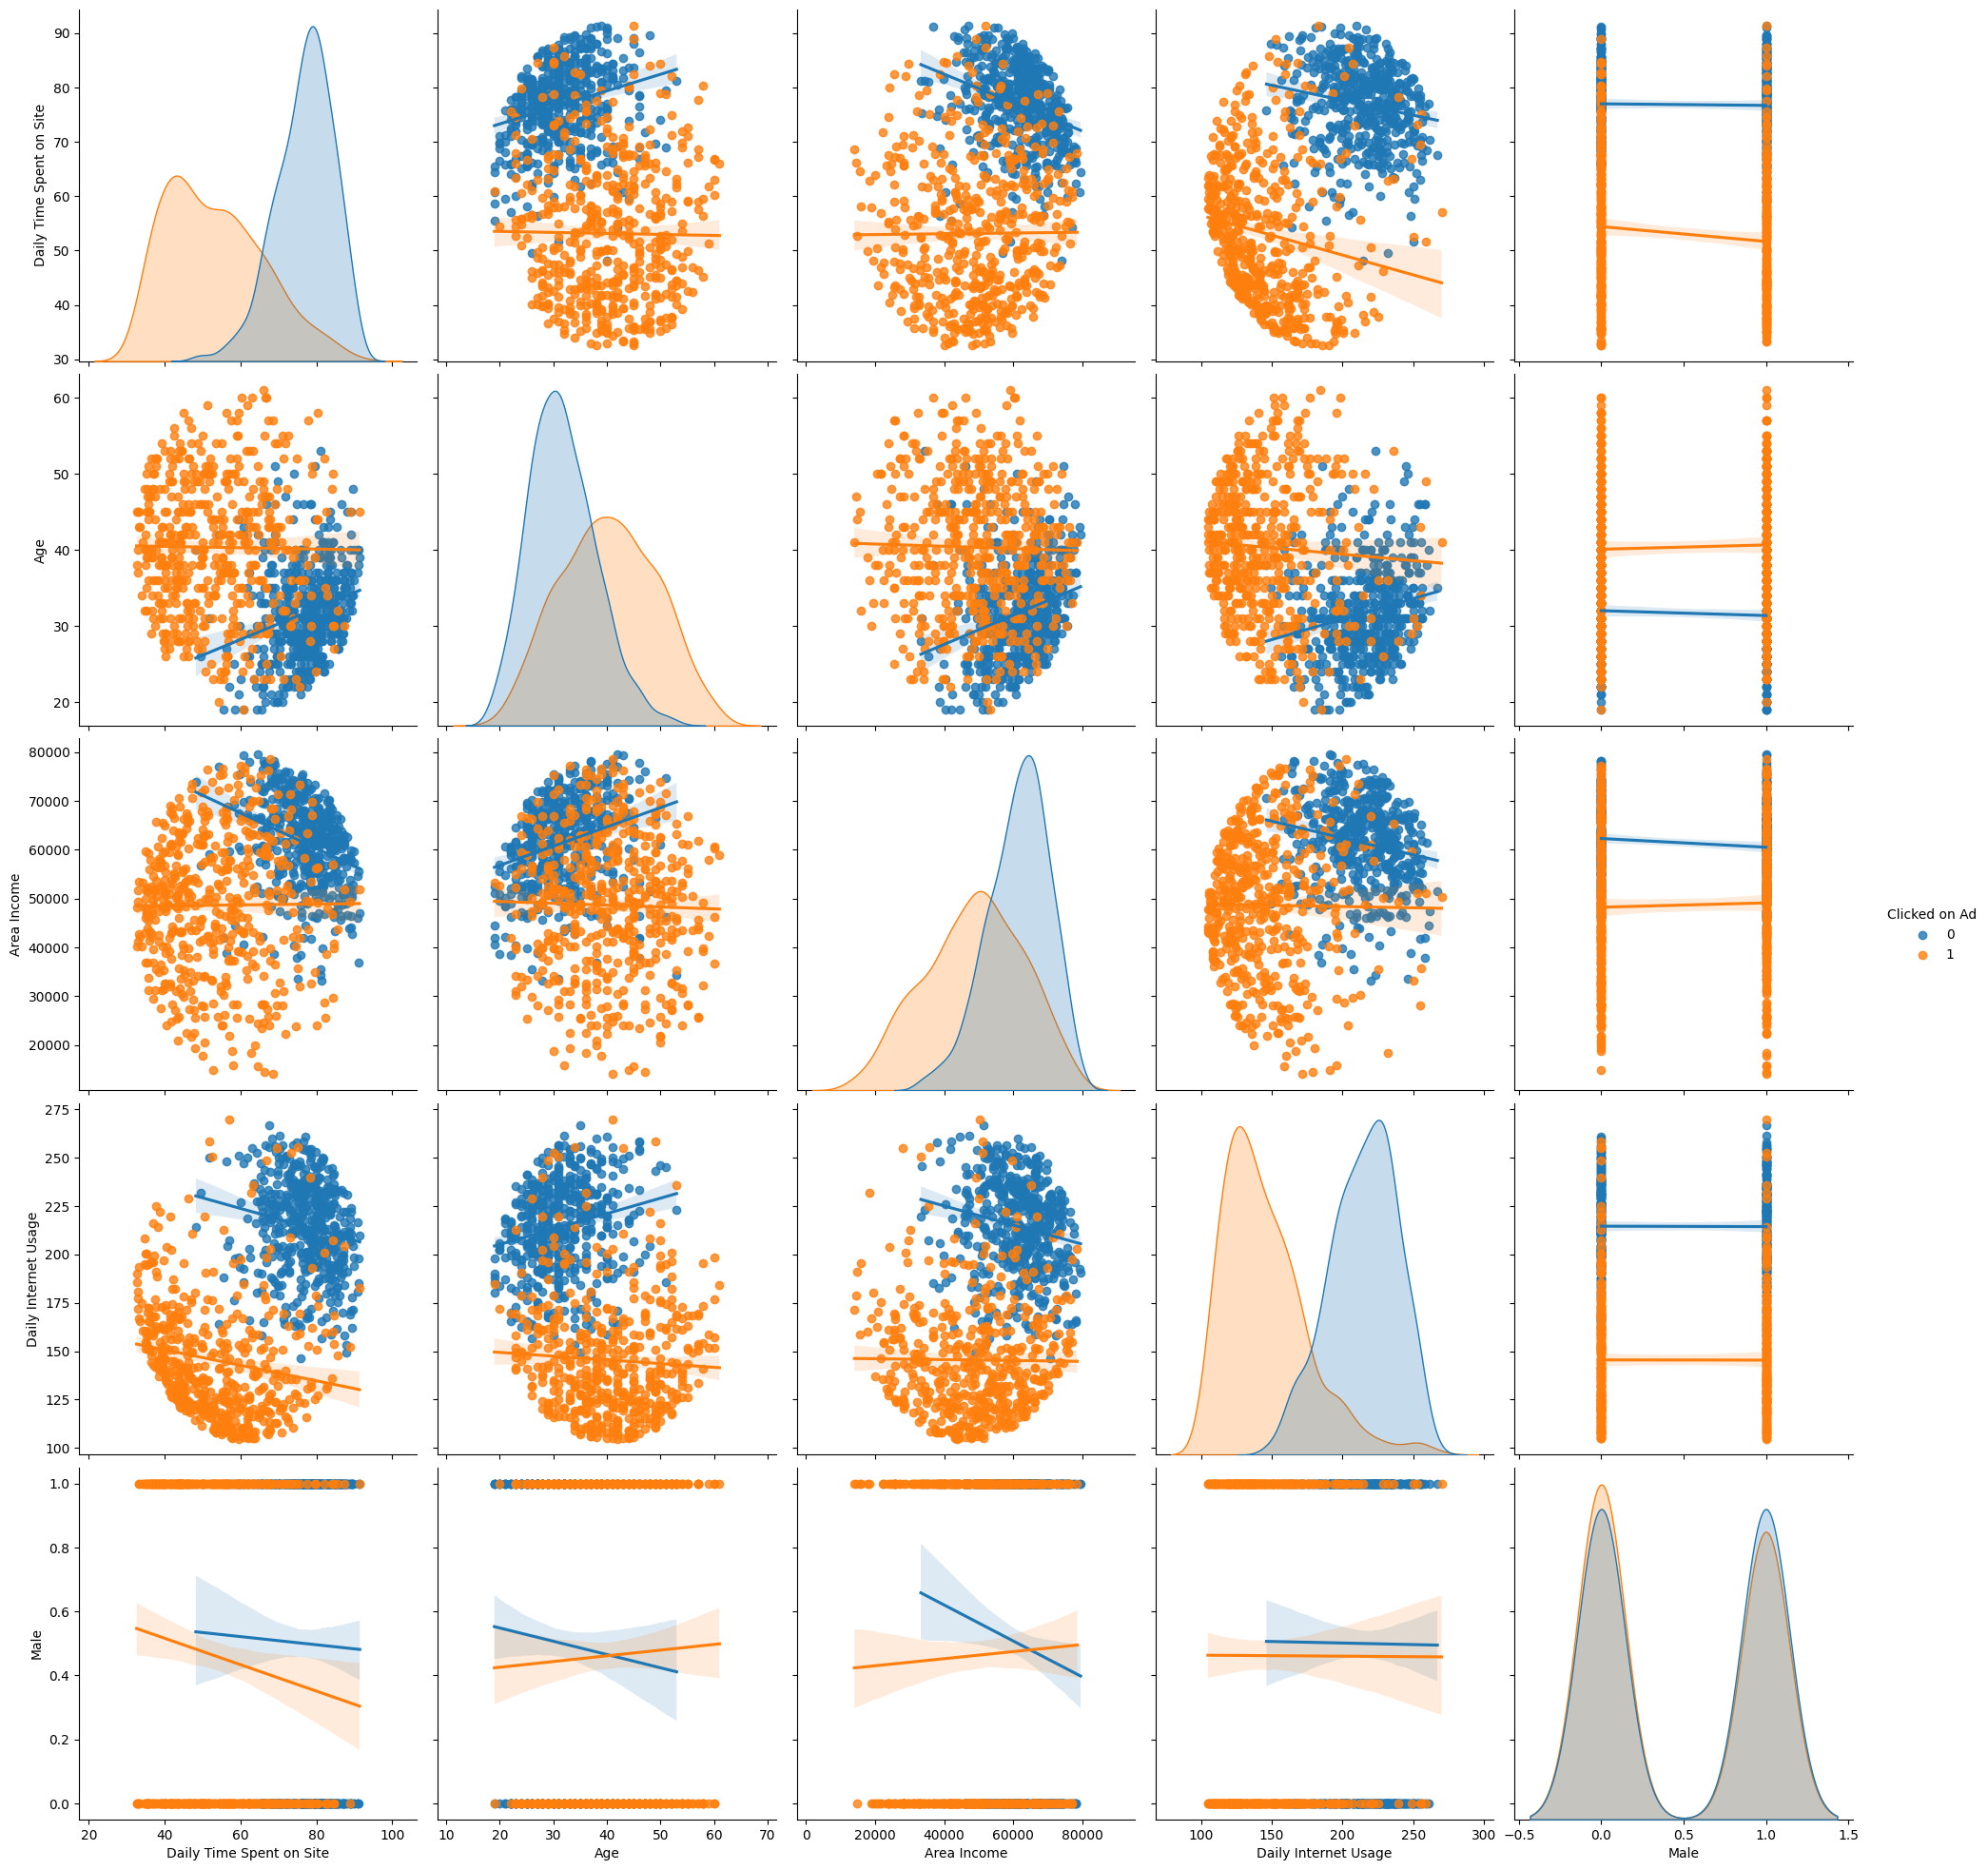

In [9]:
sns.pairplot(df,
            hue='Clicked on Ad',
            height=4,
            vars=["Daily Time Spent on Site", "Age","Area Income","Daily Internet Usage",'Male'],
            kind='reg'); # "reg" de regresión lineal

<Axes: >

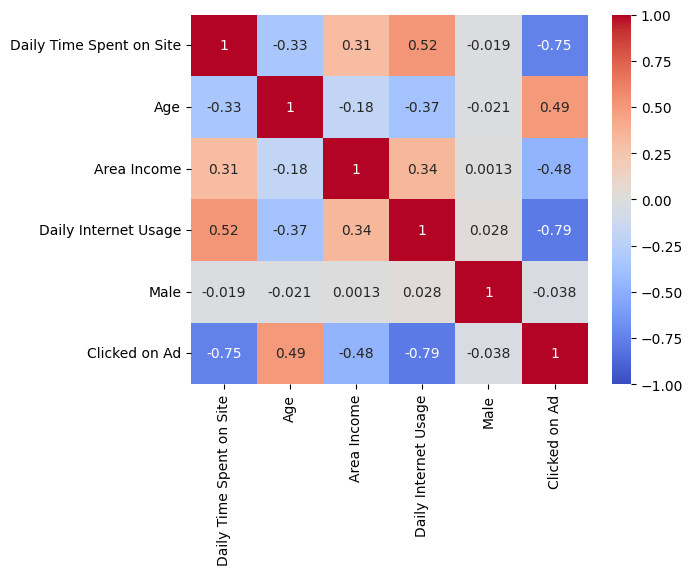

In [10]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', vmin=-1)

# 2. Prepare Data for Logistic Regression



#### 1. Feature engineering


<Figure size 1500x2000 with 0 Axes>

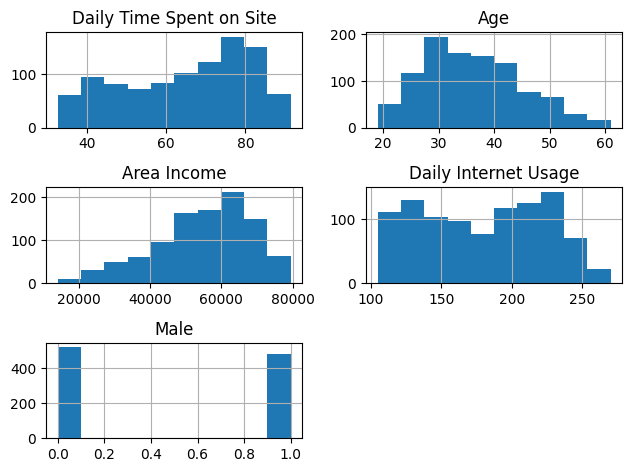

In [11]:
plt.figure(figsize=(15, 20))
df.drop(['Clicked on Ad'], axis = 1).hist()
plt.tight_layout(pad=1.0)
plt.show()

## ME QUEDO CON LAS CUATRO PRIMERAS COLUMNAS


#### 2. Train test split


In [12]:
X = df[["Daily Time Spent on Site", "Age","Area Income","Daily Internet Usage"]]
y = df['Clicked on Ad']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 4)
(200, 4)
(800,)
(200,)



#### 3. StandardScaler()


In [13]:
scaler = StandardScaler()

X_train_scal = scaler.fit_transform(X_train)
X_test_scal = scaler.transform(X_test)

# 3. Implement a Logistic Regression in Scikit-Learn and predict.

In [14]:
model = LogisticRegression(max_iter=1000)

In [15]:
model.fit (X_train_scal, y_train)

LogisticRegression(max_iter=1000)

In [16]:
y_pred = model.predict(X_test_scal)


# 4. Evaluation


#### 0. Accuracy

In [17]:
print("accuracy_score", accuracy_score(y_test, y_pred))

accuracy_score 0.945


(TP + TN) / Total predicciones

In [18]:
acierto = accuracy_score(y_test, y_pred)

error = 1 - acierto
print("Acierto:", round(acierto*100, 2), "%")
print("Error:", round(error*100, 2), "%")

Acierto: 94.5 %
Error: 5.5 %


In [19]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


#### 1. Confusion Matrix


In [72]:
c = confusion_matrix (y_test,y_pred)
c

array([[90,  6],
       [ 5, 99]])

# ** AQUÍ SE VE COMO GENERALIZA EL MODELO **

<Axes: >

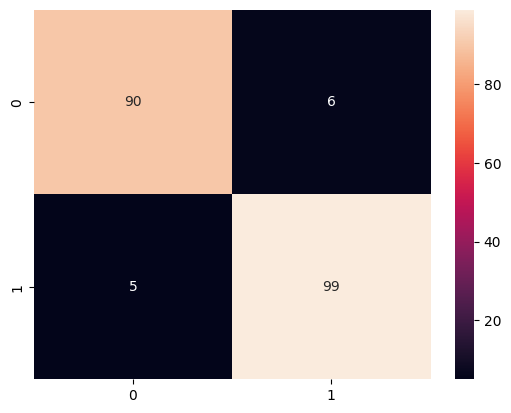

In [22]:
sns.heatmap(confusion_matrix(y_test,y_pred), annot=True)


#### 2. Precision


Cuántos son realmente 1s, de todos los que ha predicho como 1s

TP / (TP + FP)

In [23]:
p = precision_score (y_test,y_pred)
p

0.9428571428571428



#### 3. Recall


Cuántos has predicho como 1, de los que realmente eran 1s

TP / (TP + FN)

In [24]:
r = recall_score(y_test,y_pred)
r

0.9519230769230769



#### 4. F1 Score


2 * p * r / (r + p)

In [25]:
f = f1_score (y_test,y_pred)
f

0.9473684210526315



#### 5. ROC curve

In [26]:
roc = roc_auc_score (y_test,y_pred)
roc

np.float64(0.9447115384615384)

In [28]:
pred_proba = model.predict_proba(X_test_scal)
pred_proba

array([[8.71113184e-05, 9.99912889e-01],
       [1.36410960e-03, 9.98635890e-01],
       [9.90810789e-01, 9.18921053e-03],
       [8.41161512e-01, 1.58838488e-01],
       [4.11221774e-01, 5.88778226e-01],
       [4.25484413e-05, 9.99957452e-01],
       [6.21510392e-01, 3.78489608e-01],
       [9.78634467e-01, 2.13655334e-02],
       [9.94075644e-01, 5.92435563e-03],
       [9.92683436e-01, 7.31656405e-03],
       [9.93389371e-01, 6.61062913e-03],
       [4.78864407e-01, 5.21135593e-01],
       [4.90223919e-04, 9.99509776e-01],
       [3.53870604e-03, 9.96461294e-01],
       [9.88952676e-01, 1.10473243e-02],
       [9.89624177e-01, 1.03758225e-02],
       [3.24759311e-04, 9.99675241e-01],
       [9.92239990e-01, 7.76001029e-03],
       [9.86014169e-01, 1.39858310e-02],
       [9.80524046e-01, 1.94759540e-02],
       [1.60865511e-02, 9.83913449e-01],
       [9.34581112e-01, 6.54188884e-02],
       [4.33644622e-01, 5.66355378e-01],
       [3.21591232e-03, 9.96784088e-01],
       [8.324696

In [30]:
from sklearn.metrics import roc_curve
y_probs = model.predict_proba(X_test)[:, 1]  # Probabilidad de clase positiva
fpr, tpr, t = roc_curve(y_test, y_probs)


c:\Users\amaci\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(




#### 6. P-R curve

# SI TODAS LAS METRICAS DAN DENTRO DEL MISMO RANGO ES QUE LA PREDICCION ES CORRECTA